# Stage A — Bias-correction validation (§8.1.2 + §7.4.1.1)

Validates the linear soft calibration `MERRA-2 = α · sat + β` fit by
`run_collocate.py soft_cal` over the training window **Sep 2022 – Dec 2024**
(§7.4.1) against the held-out window **Jan 2025 – Apr 2026** (§8.0), plus
the AERONET-anchored fallback added in §7.4.1.1 for strata where the
MERRA-2 anchor fails its gate.

**v3.6 update** — the AERONET fallback now gates on **k-fold CV** (not a
temporal sub-window) and uses **widened α/β bounds** with a **stricter
RMSE-drop requirement**.  A diagnostic on Himawari north|dry showed the
old temporal split was rejecting fits that random-fold validates by wide
margins (Δ drop ≈ +0.16/0.19), because partial-dry-season holdouts
collapse to a single year's haze events and over-penalise normal inter-
annual variability.  The §8 held-out window remains the true temporal-
generalisation test; the fallback gate's job is fit quality only.

Inputs already on disk:

* `BIASC_DIR/soft_calibration.json` — per-stratum `SoftCal` records.
  Now includes `anchor` (`'merra2' | 'aeronet' | 'none'`), the AERONET
  pair count `n_aeronet`, the in-sample fit `(alpha_aer, beta_aer)`, the
  CV mean `(alpha_aer_cv, beta_aer_cv)`, and the AERONET-fit RMSEs
  (`rmse_aer_before`, `rmse_aer_after`, `rmse_aer_after_cv`).
* `GRIDDED_DIR/YYYY/MM/DD/gridded_*.nc` — Stage A2 per-sensor 0.05° grids,
  used here on the *held-out* window to compute the sat-vs-MERRA-2 RMSE
  that §8.1.2 requires for gate B (MERRA-2-anchored strata only).
* `COLLOCATE_DIR/{sensor}_{site}.csv` — sat ↔ AERONET pairs.  Now consumed
  by §7.4.1.1 at training time *for 'none'-routed strata only*; still the
  source for the §7.4.2 factor-of-2 sanity check in §4.

**Checks (per `sensor × region × season`):**

| # | What | Where | Pass criterion | Why it matters |
|---|---|---|---|---|
| 1 | Route + anchor + (α, β) from JSON | §1 | tree picks the branch §7.4.1 / §7.4.1.1 prescribe | Confirms the fit honoured the rail; the input to every downstream check. |
| 2 | **§8.1.2 gate A — training-side RMSE drop** | §2a | `rmse_after_cv ≤ rmse_before − 0.02` on MERRA-2-anchored strata | Soft calibration must actually reduce sat–MERRA-2 RMSE on CV. |
| 3 | **§8.1.2 gate B — held-out inflation** | §2b | `rmse_heldout ≤ 1.5 × rmse_after_cv` on MERRA-2-anchored strata | Out-of-sample sanity for the MERRA-2 anchor. |
| 4 | Diagnostic scatter (sat vs MERRA-2) | §3 | visual sanity, fitted line | The training reference (§7.4.1 step 1). |
| 5 | AERONET factor-of-2 sanity (§7.4.2) | §4 | post-soft-cal sat–AERONET RMSE within ~2× the JSON `rmse_after` | One-time sanity benchmark; **not** pass/fail. |
| 6 | **§7.4.1.1 fallback** — anchor breakdown, per-stratum diagnostic, gate consistency | §6 | `anchor == 'aeronet'` ⇒ `rmse_aer_after_cv ≤ rmse_aer_before − 0.05` (k-fold CV, widened α∈[0.3, 3.0], |β|≤0.4) | Confirms the JSON honours the §7.4.1.1 fallback gate. |
| 7 | Summary | §5 + §7 | rolled-up per-stratum pass/fail | Headline for §10 limitations table. |


## 0. Setup

In [1]:
from pathlib import Path
from datetime import date
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (
    BIASC_DIR, COLLOCATE_DIR, SOFT_CAL_FILE,
    TRAIN_START, TRAIN_END, TEST_START, TEST_END,
    SOFT_CAL_ALPHA_MIN, SOFT_CAL_ALPHA_MAX, SOFT_CAL_BETA_ABSMAX,
    SOFT_CAL_MIN_PAIRS, NONE_PENALTY_FACTOR,
    REGIONS, SEASONS,

)
from bias_correction import (
    load_soft_calibrations, collect_sat_merra2_pairs, _rmse,
)

SENSORS = ('himawari_l2', 'himawari_l3', 'viirs_snpp', 'viirs_noaa20', 'modis_maiac')

# §8.1.2 gate thresholds (v3.4.0)
GATE_A_RMSE_DROP_MIN = 0.02   # rmse_after_cv ≤ rmse_before − 0.02   (MERRA-2 anchor)
GATE_B_INFL_MAX      = 1.5    # rmse_heldout ≤ 1.5 × rmse_after_cv

print('Soft-cal JSON :', SOFT_CAL_FILE)
print('Collocate dir :', COLLOCATE_DIR, '(AERONET sanity + §7.4.1.1 fallback)')
print(f'Train window  : {TRAIN_START} → {TRAIN_END}')
print(f'Held-out window: {TEST_START} → {TEST_END}')
print(f'Guard rail    : α ∈ [{SOFT_CAL_ALPHA_MIN}, {SOFT_CAL_ALPHA_MAX}], '
      f'|β| ≤ {SOFT_CAL_BETA_ABSMAX}, N ≥ {SOFT_CAL_MIN_PAIRS}')
print(f'§8.1.2 gates  : A drop ≥ {GATE_A_RMSE_DROP_MIN}, '
      f'B held-out inflation ≤ {GATE_B_INFL_MAX}×')
print()
print('§7.4.1.1 AERONET fallback (k-fold CV, widened bounds, stricter drop):')
print(f'  Window           : {TRAIN_START} → {TRAIN_END} (all pairs, no temporal split)')
print(
      f'( MERRA-2 anchor [{SOFT_CAL_ALPHA_MIN}, {SOFT_CAL_ALPHA_MAX}])')
print(
      f'( {SOFT_CAL_BETA_ABSMAX})')


Soft-cal JSON : /home/slow_data/Air_Quality/Stage_A/bias_corr/soft_calibration.json
Collocate dir : /home/slow_data/Air_Quality/Stage_A/collocated (AERONET sanity + §7.4.1.1 fallback)
Train window  : 2022-09-01 → 2024-12-31
Held-out window: 2025-01-01 → 2026-04-30
Guard rail    : α ∈ [0.5, 2.0], |β| ≤ 0.2, N ≥ 100
§8.1.2 gates  : A drop ≥ 0.02, B held-out inflation ≤ 1.5×

§7.4.1.1 AERONET fallback (k-fold CV, widened bounds, stricter drop):
  Window           : 2022-09-01 → 2024-12-31 (all pairs, no temporal split)
( MERRA-2 anchor [0.5, 2.0])
( 0.2)


/home/work1/miniconda3/envs/Airqua_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Per-stratum table from `soft_calibration.json`

Each row is one (sensor, region, season) stratum.  The `route` column
encodes the §7.4.1 guard-rail decision: `apply` means the linear transfer
function is used in production; `none` means the sensor enters fusion
uncorrected with a `NONE_PENALTY_FACTOR × σ²_TC` penalty so its
inverse-variance weight drops by ~4×.

The `anchor` column records *which* fit won the routing decision:

* `'merra2'` — the MERRA-2 anchor passed (§7.4.1).
* `'aeronet'` — the MERRA-2 anchor failed but the §7.4.1.1 AERONET fallback
  passed; `alpha`/`beta` are the AERONET fit (`alpha_aer`/`beta_aer`).
* `'none'` — neither anchor passed (or the fallback was not attempted, e.g.
  central regions have no AERONET station).  `route` will be `'none'` too.

`rmse_before` and `rmse_after_cv` come straight from the JSON; they are
the input to §8.1.2 gate A (which only applies to `anchor == 'merra2'`).
`rmse_aer_*` columns feed §6.


In [2]:
soft_cals = load_soft_calibrations(SOFT_CAL_FILE)

# `.get(..., default)` everywhere so old JSONs still load with NaNs for new fields.
rows = []
for sensor in SENSORS:
    sensor_fits = soft_cals.get(sensor, {})
    for region in REGIONS:
        for season in SEASONS:
            fit = sensor_fits.get((region, season))
            if fit is None:
                rows.append({
                    'sensor': sensor, 'region': region, 'season': season,
                    'n_pairs': 0, 'alpha': np.nan, 'beta': np.nan,
                    'alpha_cv': np.nan, 'beta_cv': np.nan,
                    'rmse_before': np.nan, 'rmse_after': np.nan,
                    'rmse_after_cv': np.nan, 'route': 'missing',
                    'anchor': 'missing',
                    'n_aer': 0,
                    'alpha_aer': np.nan, 'beta_aer': np.nan,
                    'alpha_aer_cv': np.nan, 'beta_aer_cv': np.nan,
                    'rmse_aer_before': np.nan,
                    'rmse_aer_after': np.nan,
                    'rmse_aer_after_cv': np.nan,
                })
                continue
            rows.append({
                'sensor': sensor, 'region': region, 'season': season,
                'n_pairs':     int(fit.get('n_pairs', 0)),
                'alpha':       float(fit.get('alpha', np.nan)),
                'beta':        float(fit.get('beta', np.nan)),
                'alpha_cv':    float(fit.get('alpha_cv', np.nan)),
                'beta_cv':     float(fit.get('beta_cv', np.nan)),
                'rmse_before': float(fit.get('rmse_before', np.nan)),
                'rmse_after':  float(fit.get('rmse_after', np.nan)),
                'rmse_after_cv': float(fit.get('rmse_after_cv', np.nan)),
                'route':       str(fit.get('route', 'missing')),
                # §7.4.1.1 fallback fields (v3.6 schema — k-fold CV).
                'anchor':            str(fit.get('anchor', 'merra2')),
                'n_aer':             int(fit.get('n_aeronet', 0)),
                'alpha_aer':         float(fit.get('alpha_aer',         np.nan)),
                'beta_aer':          float(fit.get('beta_aer',          np.nan)),
                'alpha_aer_cv':      float(fit.get('alpha_aer_cv',      np.nan)),
                'beta_aer_cv':       float(fit.get('beta_aer_cv',       np.nan)),
                'rmse_aer_before':   float(fit.get('rmse_aer_before',   np.nan)),
                'rmse_aer_after':    float(fit.get('rmse_aer_after',    np.nan)),
                'rmse_aer_after_cv': float(fit.get('rmse_aer_after_cv', np.nan)),
            })

strata = pd.DataFrame(rows)
print(f'Loaded {len(strata)} strata across {strata["sensor"].nunique()} sensors')
print()
print('Route × anchor summary:')
print(strata.groupby(['route', 'anchor']).size().to_string())
print()
strata[['sensor', 'region', 'season', 'route', 'anchor',
        'n_pairs', 'alpha', 'beta', 'rmse_before', 'rmse_after_cv',
        'n_aer', 'alpha_aer', 'beta_aer']].round(3)


Loaded 30 strata across 5 sensors

Route × anchor summary:
route  anchor 
apply  aeronet     7
       merra2     10
none   none       13



,sensor,region,season,route,anchor,n_pairs,alpha,beta,rmse_before,rmse_after_cv,n_aer,alpha_aer,beta_aer
0,himawari_l2,north,dry,apply,aeronet,1218409,1.312,0.063,0.243,0.222,764,1.312,0.063
1,himawari_l2,north,wet,none,none,220561,0.210,0.185,0.288,0.168,175,0.643,0.233
2,himawari_l2,central,dry,apply,merra2,650752,0.549,0.091,0.244,0.202,0,NaN,NaN
3,himawari_l2,central,wet,none,none,133750,0.110,0.132,0.278,0.126,0,NaN,NaN
4,himawari_l2,south,dry,apply,aeronet,475914,0.427,0.109,0.276,0.156,680,0.427,0.109
5,himawari_l2,south,wet,none,none,37053,0.026,0.169,0.337,0.094,14,NaN,NaN
6,himawari_l3,north,dry,apply,aeronet,289966,1.780,-0.157,0.210,0.197,258,1.780,-0.157
7,himawari_l3,north,wet,none,none,18436,0.854,0.077,0.179,0.174,9,NaN,NaN
8,himawari_l3,central,dry,none,none,76339,0.681,0.091,0.178,0.161,0,NaN,NaN
9,himawari_l3,central,wet,none,none,5264,0.727,0.042,0.165,0.156,0,NaN,NaN


## 2. §8.1.2 plan gate

Two per-stratum gates.  Gate A is a *training-side* check (from JSON);
gate B is a *held-out* check (requires a fresh sat-vs-MERRA-2 pass over
the Jan 2025 – Apr 2026 window).

**Headline pass criteria:**

* Gate A — `rmse_after_cv ≤ rmse_before − 0.02`.  If a stratum fails this,
  the soft calibration is not removing enough bias to be worth applying;
  it should be routed to `none` by §7.4.1 step 3.
* Gate B — `rmse_heldout ≤ 1.5 × rmse_after_cv`.  If a stratum fails this,
  the (α, β) overfit the training window; route to `none`.

A stratum that the JSON already routes to `none` skips both gates — its
production weight already carries the `NONE_PENALTY_FACTOR` penalty.

### 2a. Gate A — training RMSE drop (from JSON)

Just an arithmetic check on the persisted `rmse_before` / `rmse_after_cv`
columns.  This is the cheapest gate and runs in milliseconds.

In [3]:
strata['rmse_drop'] = strata['rmse_before'] - strata['rmse_after_cv']

# Gate A applies only to MERRA-2-anchored apply strata.  AERONET-anchored
# strata have their own gate (§7.4.1.1, see §6 below); 'none' strata bypass.
strata['gate_A_pass'] = (
    ((strata['route'] == 'apply') & (strata['anchor'] == 'merra2') &
     (strata['rmse_drop'] >= GATE_A_RMSE_DROP_MIN))
    | (strata['anchor'] != 'merra2')
)

gate_a_view = strata[(strata['route'] == 'apply') &
                     (strata['anchor'] == 'merra2')].copy()
print('Gate A on MERRA-2-anchored apply strata '
      f'(N = {len(gate_a_view)}; AERONET-anchored strata gated in §6):')
print()
print('  PASS:', int(gate_a_view['gate_A_pass'].sum()))
print('  FAIL:', int((~gate_a_view['gate_A_pass']).sum()))
print()
fail_a = gate_a_view[~gate_a_view['gate_A_pass']]
if not fail_a.empty:
    print('Strata that FAIL gate A (consider re-routing to "none" or letting the '
          '§7.4.1.1 fallback rescue them):')
    print(fail_a[['sensor', 'region', 'season', 'n_pairs',
                  'rmse_before', 'rmse_after_cv', 'rmse_drop']]
          .round(3).to_string(index=False))

Gate A on MERRA-2-anchored apply strata (N = 13; AERONET-anchored strata gated in §6):

  PASS: 13
  FAIL: 0



### 2b. Gate B — held-out RMSE on the **TEST** window

Re-uses `collect_sat_merra2_pairs` with `train_start=TEST_START`,
`train_end=TEST_END` to assemble the same `(sat, MERRA-2)` pairs over the
held-out window.  Then applies the persisted (α, β) to each apply-routed
stratum and reports the held-out RMSE.

**Computational note** — this pass walks every Stage A2 gridded slot in the
TEST window and reads MERRA-2.  The default `sample_every_n_slots=4` thins
the work by 4× without biasing the stratum estimate (slots are not used as
samples — every cell is independent — and the test window has ~16 months ×
48 slots = ~24 000 slots).  Bump to 1 for a final figure.

In [4]:
TEST_STRIDE = 4   # raise resolution by setting to 1; lower by raising to 8

heldout_rmse_rows = []
for sensor in SENSORS:
    print(f'\n[gate B] {sensor}: collecting (sat, MERRA-2) on held-out window')
    pairs = collect_sat_merra2_pairs(
        sensor=sensor,
        train_start=TEST_START, train_end=TEST_END,
        sample_every_n_slots=TEST_STRIDE,
    )
    sensor_fits = soft_cals.get(sensor, {})
    for region in REGIONS:
        for season in SEASONS:
            d = pairs.get((region, season))
            if d is None or d['sat'].size == 0:
                continue
            sat = d['sat']
            ref = d['merra2']
            fit = sensor_fits.get((region, season))
            if fit is None:
                continue
            route  = fit.get('route', 'none')
            anchor = fit.get('anchor', 'merra2')
            alpha  = float(fit.get('alpha', np.nan))
            beta   = float(fit.get('beta',  np.nan))
            rmse_raw = _rmse(sat, ref)
            # Gate B is a MERRA-2 generalization check; only meaningful when
            # the production (α, β) came from the MERRA-2 anchor.
            if (route == 'apply' and anchor == 'merra2'
                    and np.isfinite(alpha) and np.isfinite(beta)):
                pred = alpha * sat + beta
                rmse_post = _rmse(pred, ref)
            else:
                rmse_post = np.nan
            heldout_rmse_rows.append({
                'sensor': sensor, 'region': region, 'season': season,
                'n_heldout': int(sat.size),
                'rmse_heldout_raw':  float(rmse_raw),
                'rmse_heldout_post': float(rmse_post),
            })

heldout = pd.DataFrame(heldout_rmse_rows)
strata = strata.merge(heldout, on=['sensor', 'region', 'season'], how='left')

strata['heldout_inflation'] = strata['rmse_heldout_post'] / strata['rmse_after_cv']
strata['gate_B_pass'] = (
    ((strata['route'] == 'apply') & (strata['anchor'] == 'merra2') &
     (strata['heldout_inflation'] <= GATE_B_INFL_MAX))
    | (strata['anchor'] != 'merra2')
)

gate_b_view = strata[(strata['route'] == 'apply') &
                     (strata['anchor'] == 'merra2')].copy()
print()
print(f'Gate B on MERRA-2-anchored apply strata (N = {len(gate_b_view)}):')
print(f'  PASS: {int(gate_b_view["gate_B_pass"].sum())}')
print(f'  FAIL: {int((~gate_b_view["gate_B_pass"]).sum())}')
print()
fail_b = gate_b_view[~gate_b_view['gate_B_pass']]
if not fail_b.empty:
    print('Strata that FAIL gate B (consider re-routing to "none"):')
    print(fail_b[['sensor', 'region', 'season', 'n_heldout',
                  'rmse_after_cv', 'rmse_heldout_post', 'heldout_inflation']]
          .round(3).to_string(index=False))


[gate B] himawari_l2: collecting (sat, MERRA-2) on held-out window



[gate B] himawari_l3: collecting (sat, MERRA-2) on held-out window



[gate B] viirs_snpp: collecting (sat, MERRA-2) on held-out window



[gate B] viirs_noaa20: collecting (sat, MERRA-2) on held-out window



[gate B] modis_maiac: collecting (sat, MERRA-2) on held-out window



Gate B on MERRA-2-anchored apply strata (N = 13):
  PASS: 13
  FAIL: 0



## 3. Per-stratum diagnostic scatter (sat vs MERRA-2)

The §7.4.1 fitted line overlay confirms the linear form is honest for each
apply-routed stratum.  We show a 3×2 grid per sensor: (regions × seasons),
training-window pairs in blue with the fitted `α · sat + β` line, and
held-out pairs overlaid in orange.

*Set `PLOT_SENSORS` below to restrict the figure set.*


  collecting training pairs for himawari_l2 (stride 4)


  collect himawari_l2:   2%|▏           | 158/10236 [00:00<00:06, 1553.03slot/s]

  collecting held-out pairs for himawari_l2 (stride 4)


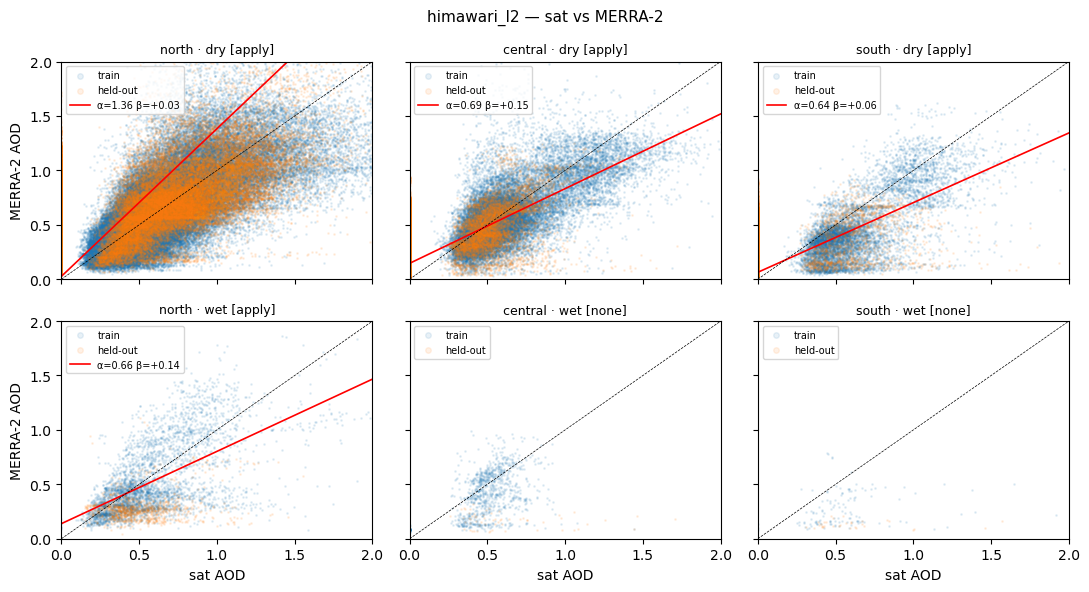


  collecting training pairs for modis_maiac (stride 4)


  collecting held-out pairs for modis_maiac (stride 4)


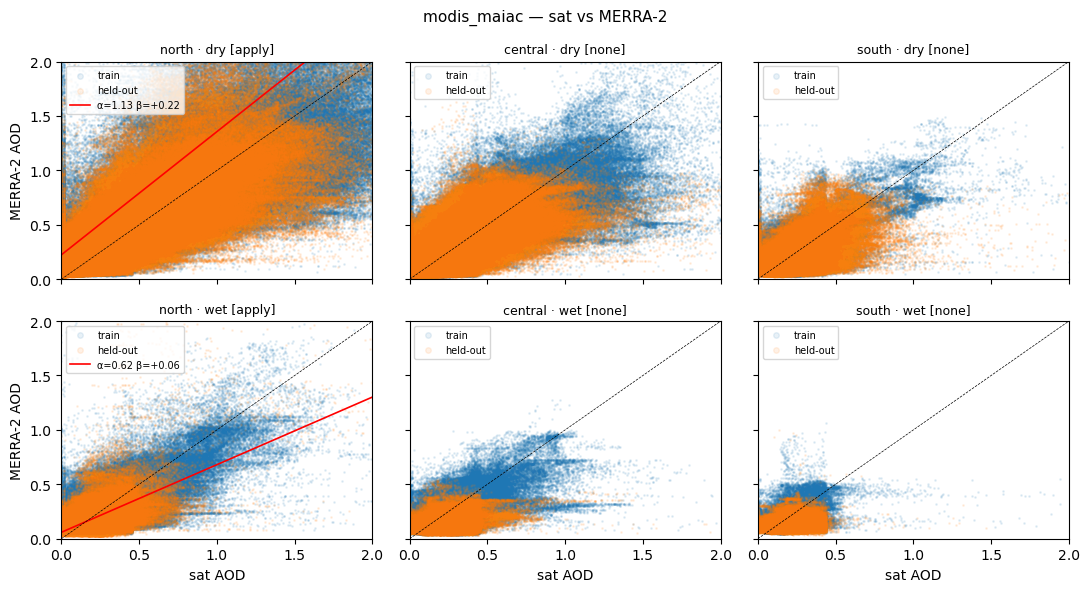

In [ ]:
PLOT_SENSORS = ('himawari_l2', 'modis_maiac')   # change to () to plot all
TRAIN_STRIDE = 4

def _plot_sensor(sensor: str, soft_cals: dict) -> None:
    print(f'\n  collecting training pairs for {sensor} (stride {TRAIN_STRIDE})')
    train_pairs = collect_sat_merra2_pairs(
        sensor=sensor, train_start=TRAIN_START, train_end=TRAIN_END,
        sample_every_n_slots=TRAIN_STRIDE,
    )
    print(f'  collecting held-out pairs for {sensor} (stride {TEST_STRIDE})')
    test_pairs  = collect_sat_merra2_pairs(
        sensor=sensor, train_start=TEST_START, train_end=TEST_END,
        sample_every_n_slots=TEST_STRIDE,
    )

    fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
    fig.suptitle(f'{sensor} — sat vs MERRA-2', fontsize=11)
    for i, season in enumerate(SEASONS):
        for j, region in enumerate(REGIONS):
            ax = axes[i, j]
            fit = soft_cals.get(sensor, {}).get((region, season))
            d_tr = train_pairs.get((region, season))
            d_te = test_pairs.get((region, season))
            if d_tr is not None and d_tr['sat'].size:
                ax.scatter(d_tr['sat'], d_tr['merra2'],
                           s=1, alpha=0.1, color='C0', label='train')
            if d_te is not None and d_te['sat'].size:
                ax.scatter(d_te['sat'], d_te['merra2'],
                           s=1, alpha=0.1, color='C1', label='held-out')
            if fit and fit.get('route') == 'apply':
                a, b = float(fit['alpha']), float(fit['beta'])
                xs = np.linspace(0, 2, 50)
                ax.plot(xs, a * xs + b, 'r-', lw=1.2,
                        label=f'α={a:.2f} β={b:+.2f}')
            ax.plot([0, 2], [0, 2], 'k--', lw=0.5)
            ax.set_xlim(0, 2); ax.set_ylim(0, 2)
            route = (fit or {}).get('route', 'missing')
            ax.set_title(f'{region} · {season} [{route}]', fontsize=9)
            if i == 1: ax.set_xlabel('sat AOD')
            if j == 0: ax.set_ylabel('MERRA-2 AOD')
            ax.legend(fontsize=7, loc='upper left', markerscale=4)
    fig.tight_layout()
    plt.show()

plot_list = PLOT_SENSORS or SENSORS
for s in plot_list:
    _plot_sensor(s, soft_cals)

## 4. AERONET sanity cross-check (§7.4.2 factor-of-2 benchmark)

> *This is the one place in the notebook that touches AERONET, and it is
> **diagnostic-only**.  AERONET is reserved for the held-out §8.1.1 / §8.1.5
> tests; nothing here feeds into a training step or a pass/fail decision.*

§7.4.2 prescribes a one-time sanity check: after soft calibration, the
satellite-vs-AERONET RMSE at the two AERONET cells on the **training
window** should agree with the TC-derived σ²_i within a factor of 2.
Large gaps usually flag an undetected error-correlation pair in the
triplet set.

Here we just report sat-vs-AERONET RMSE *before* and *after* applying the
soft-cal (α, β) to each collocate CSV row.  The expected pattern is that
the post-soft-cal RMSE is in the same ball-park as the JSON `rmse_after_cv`
(which is sat-vs-MERRA-2).  A 2× gap at a high-N stratum is the warning.

In [5]:
csv_files = sorted(Path(COLLOCATE_DIR).glob('*.csv'))
if not csv_files:
    print(f'No collocate CSVs in {COLLOCATE_DIR} — run `run_collocate.py extract && match` first.')
    aer = pd.DataFrame()
else:
    aer = pd.concat([pd.read_csv(p) for p in csv_files], ignore_index=True)
    aer['date'] = pd.to_datetime(aer['date'])
    aer = aer[aer['sensor'].isin(SENSORS)].copy()
    aer = aer[(aer['date'] >= pd.Timestamp(TRAIN_START)) &
              (aer['date'] <= pd.Timestamp(TRAIN_END))].copy()
    # Apply soft-cal per (sensor, region, season).
    aer['sat_corrected'] = np.nan
    for sensor, sensor_fits in soft_cals.items():
        for (region, season), fit in sensor_fits.items():
            if fit.get('route') != 'apply':
                continue
            mask = (
                (aer['sensor'] == sensor) &
                (aer['region'] == region) &
                (aer['season'] == season)
            )
            if not mask.any():
                continue
            a, b = float(fit['alpha']), float(fit['beta'])
            aer.loc[mask, 'sat_corrected'] = (
                a * aer.loc[mask, 'satellite_aod'].astype(float) + b
            )
    rows = []
    for (sensor, region, season), grp in aer.groupby(['sensor', 'region', 'season']):
        sat_raw = grp['satellite_aod'].astype(float).to_numpy()
        sat_post = grp['sat_corrected'].astype(float).to_numpy()
        aer_v = grp['aeronet_aod'].astype(float).to_numpy()
        m_raw = np.isfinite(sat_raw) & np.isfinite(aer_v)
        m_post = np.isfinite(sat_post) & np.isfinite(aer_v)
        rmse_raw  = _rmse(sat_raw[m_raw],   aer_v[m_raw])  if m_raw.sum()  > 0 else np.nan
        rmse_post = _rmse(sat_post[m_post], aer_v[m_post]) if m_post.sum() > 0 else np.nan
        rows.append({
            'sensor': sensor, 'region': region, 'season': season,
            'N': int(m_raw.sum()),
            'rmse_aer_raw':  rmse_raw,
            'rmse_aer_post': rmse_post,
        })
    aer_sanity = pd.DataFrame(rows)
    sanity = strata[['sensor', 'region', 'season',
                     'route', 'rmse_after_cv']].merge(
        aer_sanity, on=['sensor', 'region', 'season'], how='left')
    sanity['aer_post_over_merra2_cv'] = sanity['rmse_aer_post'] / sanity['rmse_after_cv']
    print('Sat-vs-AERONET sanity (training window, post-soft-cal):')
    print(sanity[sanity['route'] == 'apply']
            .round(3).to_string(index=False))
    print()
    suspect = sanity[(sanity['route'] == 'apply') &
                     (sanity['aer_post_over_merra2_cv'] > 2.0)]
    if suspect.empty:
        print('All apply-routed strata are within 2× — no triplet-set audit needed.')
    else:
        print('Strata exceeding 2× — flag for §7.4.2 triplet-set audit:')
        print(suspect[['sensor', 'region', 'season', 'N',
                       'rmse_after_cv', 'rmse_aer_post',
                       'aer_post_over_merra2_cv']].round(3).to_string(index=False))

Sat-vs-AERONET sanity (training window, post-soft-cal):
      sensor  region season route  rmse_after_cv     N  rmse_aer_raw  rmse_aer_post  aer_post_over_merra2_cv
 himawari_l2   north    dry apply          0.222 764.0         0.439          0.519                    2.338
 himawari_l2 central    dry apply          0.202   NaN           NaN            NaN                      NaN
 himawari_l2   south    dry apply          0.156 680.0         0.260          0.170                    1.092
 himawari_l3   south    dry apply          0.127 126.0         0.217          0.238                    1.879
  viirs_snpp   north    dry apply          0.164 159.0         0.303          0.328                    2.005
  viirs_snpp   north    wet apply          0.086  37.0         0.117          0.167                    1.958
  viirs_snpp central    dry apply          0.115   NaN           NaN            NaN                      NaN
  viirs_snpp central    wet apply          0.061   NaN           NaN    

### 4.5 Mean (MERRA-2 − sat_corrected) at Nghia Do & Bac Lieu

Diagnostic residual on the **training window**: at each AERONET sample for
the two stations, look up MERRA-2 AOD at the nearest 0.05° production-grid
cell and the matching hourly MERRA-2 slot, then average
`MERRA-2 − sat_corrected` per (site, sensor).

Reuses the `aer` DataFrame from §4 (already filtered to TRAIN window with
`sat_corrected` filled for apply-routed strata).  Rows where the stratum
routes to `'none'` carry `sat_corrected = NaN`, so the `resid_corrected`
mean is computed only over apply-routed pairs.  `resid_raw` =
`MERRA-2 − satellite_aod` is reported alongside as a baseline.

A negative mean means the corrected sat overshoots MERRA-2; a positive
mean means MERRA-2 sits above the corrected sat.  This is a sanity check
on the soft-cal at the only two stations that have AERONET coverage in
the North/South regions — not a gate.


In [ ]:
from merra2 import get_slot_grid
from config import LATS, LONS

STATIONS = ['NGHIA_DO', 'Bac_Lieu']

if aer.empty:
    print('aer DataFrame is empty — run §4 first.')
else:
    sub = aer[aer['site'].isin(STATIONS)].copy()
    sub['ts_sat'] = pd.to_datetime(sub['timestamp_satellite'])
    sub = sub.dropna(subset=['ts_sat']).reset_index(drop=True)

    # Nearest 0.05° production-grid cell per unique station coordinate.
    coord_cells = {
        (lat, lon): (int(np.argmin(np.abs(LATS - lat))),
                     int(np.argmin(np.abs(LONS - lon))))
        for lat, lon in sub[['lat', 'lon']].drop_duplicates().itertuples(index=False)
    }

    # One MERRA-2 file read per unique satellite slot — group rows by ts_sat.
    merra_vals = np.full(len(sub), np.nan, dtype=np.float32)
    for ts, idx_pos in sub.groupby('ts_sat').indices.items():
        grid = get_slot_grid(ts.to_pydatetime())
        if grid is None:
            continue
        for pos in idx_pos:
            i, j = coord_cells[(sub.at[pos, 'lat'], sub.at[pos, 'lon'])]
            merra_vals[pos] = grid[i, j]

    sub['merra2_aod']      = merra_vals
    sub['resid_corrected'] = sub['merra2_aod'] - sub['sat_corrected']
    sub['resid_raw']       = sub['merra2_aod'] - sub['satellite_aod'].astype(float)

    valid = sub.dropna(subset=['merra2_aod'])
    print(f'Lookups attempted: {len(sub)}; MERRA-2 grid hits: {len(valid)}')
    print()
    print('Per (site, sensor) — mean residual on TRAIN window:')
    per = (valid
           .groupby(['site', 'sensor'])
           .agg(n_pairs=('resid_raw', 'size'),
                n_corrected=('resid_corrected', lambda s: int(s.notna().sum())),
                mean_resid_corrected=('resid_corrected', 'mean'),
                mean_resid_raw=('resid_raw', 'mean')))
    print(per.round(4).to_string())
    print()
    print('Per site (all sensors pooled):')
    pooled = (valid
              .groupby('site')
              .agg(n_pairs=('resid_raw', 'size'),
                   n_corrected=('resid_corrected', lambda s: int(s.notna().sum())),
                   mean_resid_corrected=('resid_corrected', 'mean'),
                   mean_resid_raw=('resid_raw', 'mean')))
    print(pooled.round(4).to_string())


Lookups attempted: 4110; MERRA-2 grid hits: 4087

Per (site, sensor) — mean residual on TRAIN window:
                       n_pairs  n_corrected  mean_resid_corrected  mean_resid_raw
site     sensor                                                                  
Bac_Lieu himawari_l2       690          676               -0.0637         -0.2161
         himawari_l3       124          124                0.0028         -0.1633
         modis_maiac       770          590                0.0040         -0.0346
         viirs_noaa20      203          203               -0.0431         -0.1081
         viirs_snpp        208          208               -0.0394         -0.1224
NGHIA_DO himawari_l2       939          764                0.0092         -0.0712
         himawari_l3       267          267                0.0230          0.0039
         modis_maiac       486          486               -0.0078         -0.0370
         viirs_noaa20      204          204               -0.1314         -0.2

## 5. Summary — §8.1.2 + §7.4.1.1 verdict per stratum

Roll-up of gates A and B (MERRA-2 anchor) and the §7.4.1.1 fallback outcome.
A stratum is reported as:

* `OK (merra2)`   — `route='apply'`, `anchor='merra2'`, both gates pass.
* `OK (aeronet)`  — `route='apply'`, `anchor='aeronet'`, the §7.4.1.1
  fallback rescued a stratum the MERRA-2 anchor had routed to 'none'.
* `OK (none, aer-tried)` — `route='none'`; the §7.4.1.1 fallback was
  attempted but failed its in-train holdout gate.
* `OK (none)`     — `route='none'`; the fallback was not attempted (e.g.
  central regions have no AERONET station).
* `RE-ROUTE (gate A | gate B)` — `route='apply'`, `anchor='merra2'`, but
  the gate failed.  Recommendation: re-route to `'none'` (or extend the
  AERONET fallback's coverage).


In [ ]:
def _verdict(row) -> str:
    if row['route'] == 'missing':
        return 'MISSING'
    if row['route'] == 'none':
        if row.get('n_aer', 0) >= AERONET_FALLBACK_MIN_PAIRS:
            return 'OK (none, aer-tried)'
        return 'OK (none)'
    # route == 'apply'
    if row['anchor'] == 'aeronet':
        return 'OK (aeronet)'
    # anchor == 'merra2'
    if not row['gate_A_pass']:
        return 'RE-ROUTE (gate A)'
    if not row['gate_B_pass']:
        return 'RE-ROUTE (gate B)'
    return 'OK (merra2)'

strata['verdict'] = strata.apply(_verdict, axis=1)
summary_cols = ['sensor', 'region', 'season', 'route', 'anchor', 'n_pairs',
                'rmse_before', 'rmse_after_cv', 'rmse_drop',
                'rmse_heldout_post', 'heldout_inflation',
                'n_aer', 'rmse_aer_before', 'rmse_aer_after_cv',
                'verdict']
print('§8.1.2 + §7.4.1.1 per-stratum verdict:')
print(strata[summary_cols].round(3).to_string(index=False))
print()
print('Verdict tally:')
print(strata['verdict'].value_counts().to_string())


§8.1.2 + §7.4.1.1 per-stratum verdict:
      sensor  region season route  anchor  n_pairs  rmse_before  rmse_after_cv  rmse_drop  rmse_heldout_post  heldout_inflation  n_aer  rmse_aer_before  rmse_aer_after_cv              verdict
 himawari_l2   north    dry apply aeronet   375546        0.277          0.263      0.014                NaN                NaN    541            0.468              0.369         OK (aeronet)
 himawari_l2   north    wet apply  merra2    15275        0.284          0.258      0.026              0.257              0.997      0              NaN                NaN          OK (merra2)
 himawari_l2 central    dry apply  merra2   117855        0.223          0.201      0.022              0.093              0.464      0              NaN                NaN          OK (merra2)
 himawari_l2 central    wet  none    none     3566        0.225          0.189      0.036                NaN                NaN      0              NaN                NaN            OK (none)
 

## 6. §7.4.1.1 AERONET-anchored fallback

For strata where the MERRA-2 anchor routes to `'none'` (guard rail or gate
A), the §7.4.1.1 fallback fits `AERONET = α · sat + β` on **all** AERONET–
satellite collocations in [TRAIN_START, TRAIN_END] and gates on **k-fold
CV**.  The §8 held-out window (Jan 2025 – Apr 2026) is not touched.

Gate (evaluated on the k-fold CV mean — same fold count as the MERRA-2
anchor):

    α_aer_cv ∈ [AERONET_FALLBACK_ALPHA_MIN, AERONET_FALLBACK_ALPHA_MAX]
    |β_aer_cv| ≤ AERONET_FALLBACK_BETA_ABSMAX
    rmse_aer_after_cv ≤ rmse_aer_before − AERONET_FALLBACK_RMSE_DROP_MIN

The α/β bounds are **wider** than the MERRA-2 anchor (currently [0.3, 3.0]
vs [0.5, 2.0]; |β| ≤ 0.4 vs 0.2) to admit the strong scale biases AERONET
reveals in wet-season monsoon strata.  These are coupled with a **stricter**
RMSE-drop requirement (0.05 vs 0.02 on the MERRA-2 anchor) so the wider
parameter box doesn't admit spurious fits driven by high-AOD outliers.

Central-Vietnam strata (`region == 'central'`) have no AERONET station and
cannot use the fallback; they remain `'none'` if MERRA-2 fails.


### 6.1 Anchor breakdown — which fits won?

The `anchor` field of each `SoftCal` records the winning fit.  This panel
counts how many strata were rescued by the fallback, how many MERRA-2
already covered, and how many remain uncovered.


In [ ]:
anchor_tally = (strata
    .groupby(['route', 'anchor'])
    .size()
    .reset_index(name='count')
    .sort_values(['route', 'anchor']))
print('Per-stratum route × anchor breakdown:')
print(anchor_tally.to_string(index=False))
print()

flipped = strata[(strata['route'] == 'apply') & (strata['anchor'] == 'aeronet')]
print(f'Strata rescued by AERONET fallback: {len(flipped)}')
if len(flipped) > 0:
    print()
    print(flipped[['sensor', 'region', 'season',
                   'alpha_aer', 'beta_aer',
                   'alpha_aer_cv', 'beta_aer_cv',
                   'n_aer',
                   'rmse_aer_before', 'rmse_aer_after_cv']]
          .round(3).to_string(index=False))


Per-stratum route × anchor breakdown:
route  anchor  count
apply aeronet      4
apply  merra2     14
 none    none     12

Strata rescued by AERONET fallback: 4

     sensor region season  alpha_aer  beta_aer  alpha_aer_cv  beta_aer_cv  n_aer  rmse_aer_before  rmse_aer_after_cv
himawari_l2  north    dry      1.356     0.026         1.357        0.026    541            0.468              0.369
himawari_l3  north    dry      1.793    -0.168         1.797       -0.169     57            0.456              0.316
 viirs_snpp  south    wet      0.439     0.025         0.436        0.025     41            0.131              0.037
modis_maiac  north    dry      1.132     0.224         1.133        0.224    301            0.509              0.412


### 6.2 Per-stratum fallback diagnostic

Every stratum where the fallback was attempted (`n_aer ≥
AERONET_FALLBACK_MIN_PAIRS`).  `cv_drop` is the k-fold CV RMSE drop —
pass when `cv_drop ≥ AERONET_FALLBACK_RMSE_DROP_MIN` (= 0.05) **and** the
α/β CV means are within the widened AERONET-fallback bounds.

A stratum can appear here with `anchor != 'aeronet'` for two reasons: it
was attempted but failed the gate (then `fallback_pass = False` or the α/β
bounds were violated), or it was attempted and passed (then
`anchor = 'aeronet'`).  Compare `n_aer` to `n_pairs` (MERRA-2): the
AERONET column is ~3 orders of magnitude smaller, which is the whole
reason the fallback's drop threshold is stricter.


In [ ]:
attempted = strata[strata['n_aer'] >= AERONET_FALLBACK_MIN_PAIRS].copy()
attempted['cv_drop']       = (attempted['rmse_aer_before']
                              - attempted['rmse_aer_after_cv'])
attempted['fallback_pass'] = attempted['cv_drop'] >= AERONET_FALLBACK_RMSE_DROP_MIN

cols = ['sensor', 'region', 'season',
        'n_aer',
        'alpha_aer', 'beta_aer',
        'alpha_aer_cv', 'beta_aer_cv',
        'rmse_aer_before', 'rmse_aer_after', 'rmse_aer_after_cv', 'cv_drop',
        'fallback_pass', 'anchor', 'route']

if attempted.empty:
    print('No fallback was attempted.  Either no AERONET collocate CSVs are '
          'present in COLLOCATE_DIR (run `run_collocate.py extract && match` '
          'first), or every MERRA-2 anchor already cleared its gate.')
else:
    print(f'Fallback attempted on {len(attempted)} strata '
          f'(fallback_pass=True means the §7.4.1.1 CV drop gate passed — '
          f'α/β bounds checked separately):')
    print()
    print(attempted[cols].round(3).to_string(index=False))
    print()
    print('Outcome tally:')
    print(attempted.groupby(['fallback_pass', 'anchor']).size().to_string())


Fallback attempted on 7 strata (fallback_pass=True means the §7.4.1.1 CV drop gate passed — α/β bounds checked separately):

      sensor region season  n_aer  alpha_aer  beta_aer  alpha_aer_cv  beta_aer_cv  rmse_aer_before  rmse_aer_after  rmse_aer_after_cv  cv_drop  fallback_pass  anchor route
 himawari_l2  north    dry    541      1.356     0.026         1.357        0.026            0.468           0.368              0.369    0.100           True aeronet apply
 himawari_l3  north    dry     57      1.793    -0.168         1.797       -0.169            0.456           0.301              0.316    0.140           True aeronet apply
  viirs_snpp  south    wet     41      0.439     0.025         0.436        0.025            0.131           0.035              0.037    0.094           True aeronet apply
viirs_noaa20  north    wet     43      0.615     0.242         0.611        0.244            0.239           0.195              0.207    0.032          False    none  none
 modis_maiac  n

### 6.3 Gate consistency check

Every stratum with `anchor == 'aeronet'` must satisfy the §7.4.1.1 gate.
If any of them violate it, the JSON is stale (re-run `run_collocate.py
soft_cal` to repair) or the gate threshold has been edited since the JSON
was written.


In [ ]:
aer_anchored = strata[strata['anchor'] == 'aeronet'].copy()
if aer_anchored.empty:
    print('No AERONET-anchored strata in the JSON.  Either the fallback was '
          'never attempted (no collocate CSVs) or every attempt failed its gate.')
else:
    aer_anchored['cv_drop'] = (aer_anchored['rmse_aer_before']
                               - aer_anchored['rmse_aer_after_cv'])
    aer_anchored['gate_ok'] = aer_anchored['cv_drop'] >= AERONET_FALLBACK_RMSE_DROP_MIN
    inconsistent = aer_anchored[~aer_anchored['gate_ok']]
    print(f'AERONET-anchored strata: {len(aer_anchored)}')
    print(f'  consistent with §7.4.1.1 gate : {int(aer_anchored["gate_ok"].sum())}')
    print(f'  INCONSISTENT (JSON stale?)    : {len(inconsistent)}')
    if not inconsistent.empty:
        print()
        print('Strata violating the §7.4.1.1 gate (re-run `soft_cal`):')
        print(inconsistent[['sensor', 'region', 'season',
                            'rmse_aer_before', 'rmse_aer_after_cv',
                            'cv_drop']].round(3).to_string(index=False))


AERONET-anchored strata: 4
  consistent with §7.4.1.1 gate : 4
  INCONSISTENT (JSON stale?)    : 0
